# Global Parameters and Database Initialization

In [1]:
import pandas as pd
import sqlite3
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

DB_PATH = "../../CCSMLDatabase.db"
TABLE = "master_clean"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query(
    f"SELECT * FROM master_clean",
    conn,
)
conn.close()

# Global style settings
plt.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth": 3, # Thicker axis lines
    "axes.spines.top": True,          
    "axes.spines.right": True,          
    "xtick.major.width": 3, # Match tick thickness to axis
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "ytick.major.width": 3,
    "xtick.direction": "out", # Ticks point outside
    "ytick.direction": "out",
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.labelweight": "normal",
})

n = df.shape[0] 
df.columns

Index(['id', 'tag', 'name', 'pubchemId', 'adduct', 'mass', 'z', 'ccs', 'smi',
       'inchikey', 'superclass', 'class', 'subclass'],
      dtype='object')

# CCS Distribution by Adduct Type

['[M+H]+', '[M-H]-', '[M+Na]+', '[M+H-H2O]+', '[M+K]+', '[M+NH4]+', '[M+HCOO]-', '[M]+', '[M+Na-2H]-', '[M+Cl]-']
Adduct → tab10 index → RGBA → HEX

[M+H]+           idx=0   RGBA=(np.float64(0.12156862745098039), np.float64(0.4666666666666667), np.float64(0.7058823529411765), np.float64(1.0))  HEX=#1f77b4
[M-H]-           idx=1   RGBA=(np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0))  HEX=#ff7f0e
[M+Na]+          idx=2   RGBA=(np.float64(0.17254901960784313), np.float64(0.6274509803921569), np.float64(0.17254901960784313), np.float64(1.0))  HEX=#2ca02c
[M+H-H2O]+       idx=3   RGBA=(np.float64(0.8392156862745098), np.float64(0.15294117647058825), np.float64(0.1568627450980392), np.float64(1.0))  HEX=#d62728
[M+K]+           idx=4   RGBA=(np.float64(0.5803921568627451), np.float64(0.403921568627451), np.float64(0.7411764705882353), np.float64(1.0))  HEX=#9467bd
[M+NH4]+         idx=5   RGBA=(np.float64(0.5490196078431373), np.float64(0.

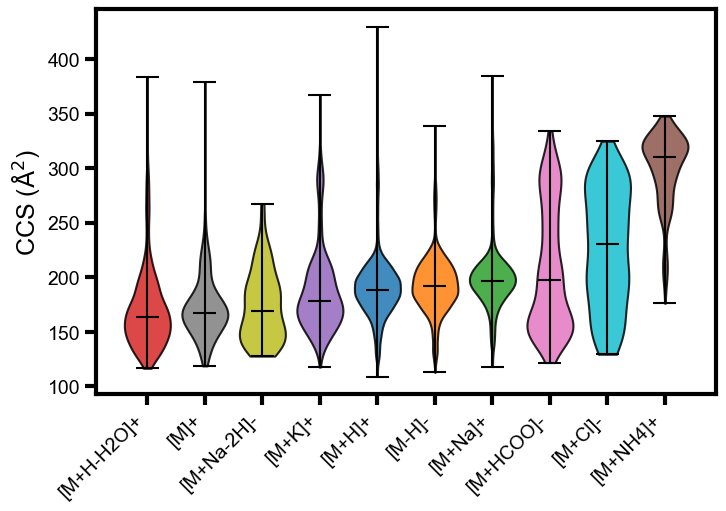

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

TOP_N = 10

# Top N most common adduct names
top_adducts = df["adduct"].value_counts().head(TOP_N).index.tolist()

# Filter dataframe to only those adducts
plot_df = df[df["adduct"].isin(top_adducts)].copy()

# Assign colors
cmap = plt.get_cmap("tab10")
ADDUCT_COLORS = {a: cmap(i) for i, a in enumerate(top_adducts)}
OTHER_COLOR = "lightgray"

print(top_adducts)
print("Adduct → tab10 index → RGBA → HEX\n")

for i, adduct in enumerate(top_adducts):
    rgba = cmap(i)
    hex_color = mcolors.to_hex(rgba)
    print(f"{adduct:15s}  idx={i:<2d}  RGBA={rgba}  HEX={hex_color}")

# Order adducts by median CCS
order = (
    plot_df.groupby("adduct")["ccs"]
    .median()
    .sort_values()
    .index
    .tolist()
)

# Build violinplot data in that order
data = [plot_df.loc[plot_df["adduct"] == a, "ccs"].values for a in order]

fig, ax = plt.subplots(figsize=(8, 5))
parts = ax.violinplot(
    data,
    positions=range(len(order)),
    widths=0.8,
    showmeans=False,
    showmedians=True,
    showextrema=True
)

for pc, adduct in zip(parts["bodies"], order):
    pc.set_facecolor(ADDUCT_COLORS.get(adduct, OTHER_COLOR))
    pc.set_edgecolor("black")
    pc.set_alpha(0.85)
    pc.set_linewidth(1.5)

for k in ("cmedians", "cbars", "cmins", "cmaxes"):
    if k in parts:
        parts[k].set_color("black")
        parts[k].set_linewidth(1.5)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_ylabel(r"CCS ($\mathrm{\AA^2}$)")

fig.savefig(
    "cc_by_adduct.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# CCS Distribution by Adduct Type

['[M+H]+', '[M-H]-', '[M+Na]+', '[M+H-H2O]+', '[M+K]+', '[M+NH4]+', '[M+HCOO]-', '[M]+', '[M+Na-2H]-', '[M+Cl]-']


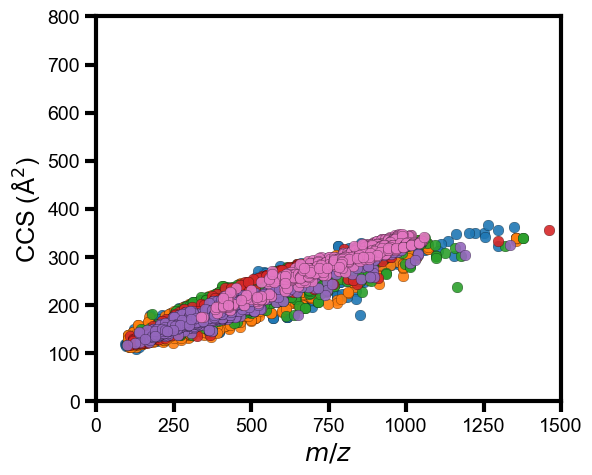

In [ ]:
TOP_SCATTER = 6
scatter_adducts = top_adducts[:TOP_SCATTER]
print(top_adducts)

fig, ax = plt.subplots(figsize=(6, 5))

# Uncomment to plot other adduct types as light gray
"""df_other = df[~df["adduct"].isin(scatter_adducts)]
ax.scatter(df_other["mass"], df_other["ccs"], alpha=0.9, s=60,
           facecolor=OTHER_COLOR, edgecolor="black", linewidth=0.2, label="Other")"""

# Define colors for top 6 adduct types 
ADDUCT_COLORS = {
    "[M+H]+":      "#1f77b4",
    "[M-H]-":      "#ff7f0e",
    "[M+Na]+":     "#2ca02c",
    "[M+NH4]+":    "#e377c2",
    "[M+H-H2O]+":  "#d62728",
    "[M+K]+":      "#9467BD",
}

# Plot top 6 adduct types by mass-CCS
for adduct in scatter_adducts:
    df_adduct = df[df["adduct"] == adduct]
    ax.scatter(df_adduct["mass"], df_adduct["ccs"], alpha=0.9, s=60,
               facecolor=ADDUCT_COLORS.get(adduct, OTHER_COLOR), edgecolor="black", linewidth=0.2,
               label=f"{adduct} (n={len(df_adduct):,})")

ax.set_ylabel(r"CCS ($\mathrm{\AA^2}$)")
ax.set_xlabel(r"$\it{m/z}$")
ax.set_xlim(0, 1500)
ax.set_ylim(0, 800)
"""ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper left"
)"""
fig.savefig(
    "mz_by_ddduct.png",
    dpi=600,
    bbox_inches="tight"
)

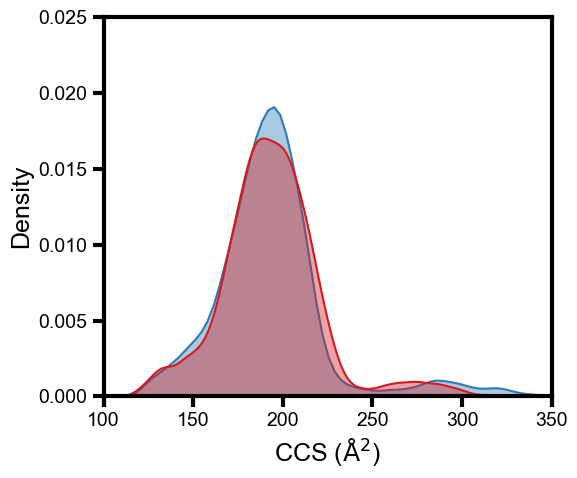

In [ ]:
# Split data by polarity
df_positive = df[df["z"] > 0]
df_negative = df[df["z"] < 0]

fig, ax = plt.subplots(figsize=(6, 5)) 

# Plot overlapping histograms with KDE
sns.kdeplot(data=df_positive, x="ccs", ax=ax, color='#2c7bb6', fill=True, alpha=0.4, 
            label=f'Positive (n={len(df_positive):,})', linewidth=1.5)
sns.kdeplot(data=df_negative, x="ccs", ax=ax, color='#d7191c', fill=True, alpha=0.4, 
            label=f'Negative (n={len(df_negative):,})', linewidth=1.5)


ax.set_xlabel(r"CCS ($\mathrm{\AA^2}$)")
ax.set_xlim(100, 350)  # limit x-axis from 0 to 1500  
ax.set_ylim(0, 0.025)
                                                                              
ax.set_ylabel("Density")
# ax.legend()

plt.tight_layout()
plt.show()
fig.savefig(
    "polarity_histogram.png",
    dpi=600,
    bbox_inches="tight"
)

# m/z histogram with median/mean markers

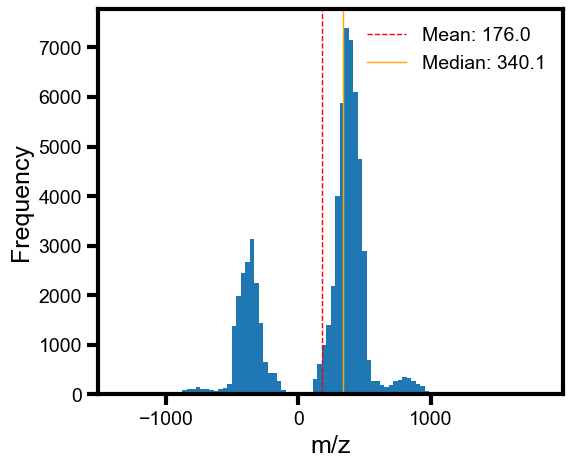

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
df["mz"] = df["mass"] / df["z"]

histogram = ax.hist(
    df["mz"],
    bins='auto'
)

#mean and median line 
ax.axvline(df["mz"].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {df["mz"].mean():.1f}')                         
ax.axvline(df["mz"].median(), color='orange', linestyle='-', linewidth=1, label=f'Median: {df["mz"].median():.1f}')                 
ax.legend(frameon=False)

ax.set_xlabel('m/z')
ax.set_ylabel('Frequency')

fig.savefig('mz_histogram.png', dpi=300, bbox_inches='tight')

# CCS histogram with median/mean markers

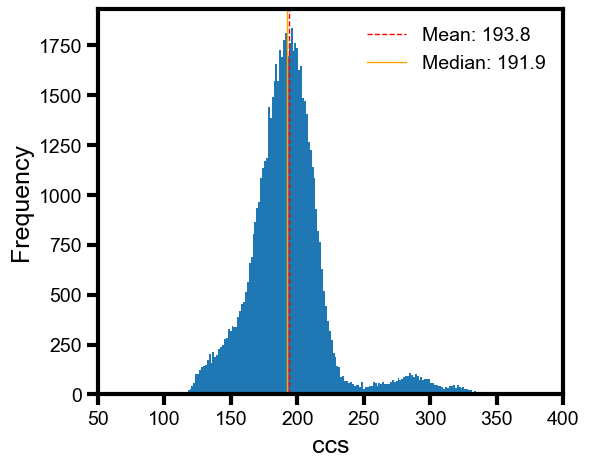

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))

histogram = ax.hist(
    df["ccs"],
    bins='auto'
)

#mean and median line 
ax.axvline(df["ccs"].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {df["ccs"].mean():.1f}')                         
ax.axvline(df["ccs"].median(), color='orange', linestyle='-', linewidth=1, label=f'Median: {df["ccs"].median():.1f}')                 
ax.legend(frameon=False)

ax.set_xlabel('ccs')
ax.set_xlim(50, 400)
ax.set_ylabel('Frequency')

fig.savefig('ccs_histogram.png', dpi=300, bbox_inches='tight')

# CCS box/whisker plots by source 

/var/folders/rd/mnd__7n57pgf3m882g88r7pw0000gn/T/ipykernel_23099/3901782290.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)


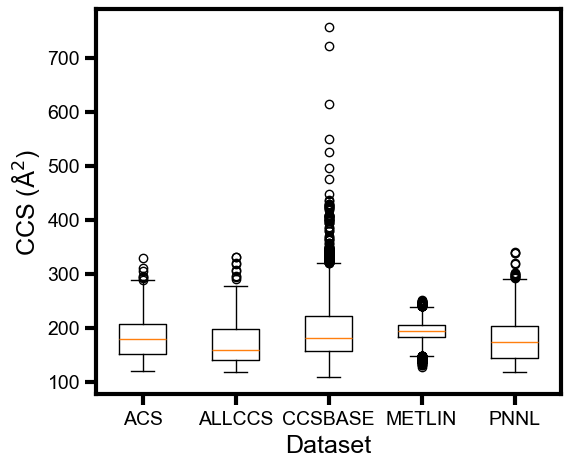

In [7]:
# split comma-delimited tags and duplicate rows
df["tag"] = df["tag"].str.split(",")
df = df.explode("tag")
df["tag"] = df["tag"].str.strip()

# prepare data + counts for plotting
tags = sorted(df["tag"].unique().tolist())
data = []
labels = []

for t in tags:
    vals = df.loc[df["tag"] == t, "ccs"].values
    data.append(vals)
    labels.append(f"{t}")


fig, ax = plt.subplots(figsize=(6, 5))

# box + whisker plots
ax.boxplot(data, labels=labels, showfliers=True)

ax.set_ylabel("CCS ($\mathrm{\AA^2}$)")
ax.set_xlabel("Dataset")

fig.savefig('ccs_boxplot_by_source.png', dpi=300, bbox_inches='tight')

# Training and Test Set CCS Histograms

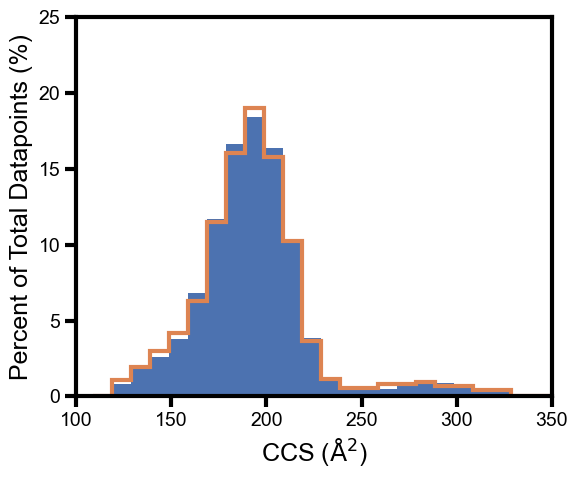

In [2]:
# Path to csv files 
csv_a = "../train_data.csv"         
csv_b = "../test_data.csv" 
# Column name
COL = "ccs"

# Load files 
df_a = pd.read_csv(csv_a)
df_b = pd.read_csv(csv_b)

ccs_a = df_a[COL].dropna().to_numpy()
ccs_b = df_b[COL].dropna().to_numpy()

# Shared 10 Å^2 bins spanning both datasets
bin_width = 10
lo = min(ccs_a.min(), ccs_b.min())
hi = max(ccs_a.max(), ccs_b.max())
bins = np.arange(lo, hi + bin_width, bin_width)

# Percent weights (each histogram sums to 100%)
w_a = np.ones_like(ccs_a) / len(ccs_a) * 100
w_b = np.ones_like(ccs_b) / len(ccs_b) * 100

fig, ax = plt.subplots(figsize=(6, 5))


ax.hist(
    ccs_a,
    bins=bins,
    weights=w_a,
    color="#4C72B0",
    # alpha=0.7,
    rwidth=1.0,
    edgecolor="none",
    label="train_data"
) 
ax.hist(
    ccs_b,
    bins=bins,
    weights=w_b,
    histtype="step",
    linewidth=3.0,
    color="#DD8452",
    label="training"
)

ax.set_xlabel("CCS ($\mathrm{\AA^2}$)")
ax.set_ylabel("Percent of Total Datapoints (%)")
ax.set_xlim(100, 350)
ax.set_ylim(0, 25)

# ax.legend(frameon=False)
plt.tight_layout()

plt.savefig(
    "Train_Test_Histogram.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

# Applicability domain via leverage (full non-hashed fingerprints)

Leverage `h = x^T (X_train^T X_train)^-1 x` measures how far a compound's fingerprint sits from the training set's descriptor space, accounting for correlation between fingerprint bits. Warning threshold `h* = 3p/n` (`p` = fingerprint columns, `n` = training molecules); compounds above it are outside the applicability domain -- the model is extrapolating for them. This is descriptor-space only (no model predictions needed), so it doesn't depend on having a trained regressor -- once one exists, standardized residuals can be added to turn this into a full Williams plot.

In [13]:
import sys, os
sys.path.append(os.path.abspath("../"))

from utils import (
    train_test_split_custom,
    calculate_sparse_fingerprints,
    build_fingerprint_vocabulary,
    build_fingerprint_index
)

def vectorize_sparse_fp(fp_dict: dict, fp_index: dict) -> np.ndarray:
    vector = np.zeros(len(fp_index), dtype=np.float32)
    for env_id, count in fp_dict.items():
        column = fp_index.get(env_id)
        if column is not None:
            vector[column] = count
    return vector


def vectorize_fingerprints(fp_dicts, fp_index) -> np.ndarray:
    return np.array([vectorize_sparse_fp(fp, fp_index) for fp in fp_dicts])


# pure data split -- no model training -- matches train.py's own default args
train_test_split_custom(
    database_file=DB_PATH,
    test_size=0.2,
    random_state=26,
    use_metlin=True,
)

train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")

print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")

50069 rows split by subclass
6162 rows split by class
30 rows split by superclass
9892 rows with no superclass/class/subclass -- added to training only
54382 train rows
11771 test rows
Train: 54382 rows | Test: 11771 rows


In [18]:
fp_min_count = 40

train_fps = calculate_sparse_fingerprints(train_df["smi"])
fp_vocab = build_fingerprint_vocabulary(train_fps, fp_min_count)
fp_index = build_fingerprint_index(fp_vocab)

test_fps = calculate_sparse_fingerprints(test_df["smi"])

X_train = vectorize_fingerprints(train_fps, fp_index).astype(np.float64)
X_test = vectorize_fingerprints(test_fps, fp_index).astype(np.float64)

p = X_train.shape[1]
n = X_train.shape[0]
print(f"Fingerprint vocabulary: {p} substructures kept (min_count={fp_min_count})")
print(f"Train: {n} molecules | Test: {len(X_test)} molecules")

Fingerprint vocabulary: 4736 substructures kept (min_count=40)
Train: 54382 molecules | Test: 11771 molecules


In [19]:
# pseudo-inverse, not a plain inverse -- fingerprint columns are collinear/sparse
# enough that X_train^T X_train is often singular or near-singular
XtX_pinv = np.linalg.pinv(X_train.T @ X_train)


def compute_leverage(X, XtX_pinv):
    return np.sum((X @ XtX_pinv) * X, axis=1)


train_leverage = compute_leverage(X_train, XtX_pinv)
test_leverage = compute_leverage(X_test, XtX_pinv)

warning_leverage = 3 * p / n

print(f"Warning leverage threshold h* = 3p/n = {warning_leverage:.4f}")
print(f"Train molecules above threshold: {(train_leverage > warning_leverage).sum()} / {n} "
      f"({(train_leverage > warning_leverage).mean() * 100:.1f}%)")
print(f"Test molecules above threshold (outside applicability domain): "
      f"{(test_leverage > warning_leverage).sum()} / {len(test_leverage)} "
      f"({(test_leverage > warning_leverage).mean() * 100:.1f}%)")

/var/folders/rd/mnd__7n57pgf3m882g88r7pw0000gn/T/ipykernel_25665/4137010015.py:3: RuntimeWarning: divide by zero encountered in matmul
  XtX_pinv = np.linalg.pinv(X_train.T @ X_train)
/var/folders/rd/mnd__7n57pgf3m882g88r7pw0000gn/T/ipykernel_25665/4137010015.py:3: RuntimeWarning: overflow encountered in matmul
  XtX_pinv = np.linalg.pinv(X_train.T @ X_train)
/var/folders/rd/mnd__7n57pgf3m882g88r7pw0000gn/T/ipykernel_25665/4137010015.py:3: RuntimeWarning: invalid value encountered in matmul
  XtX_pinv = np.linalg.pinv(X_train.T @ X_train)
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value enco

Warning leverage threshold h* = 3p/n = 0.2613
Train molecules above threshold: 968 / 54382 (1.8%)
Test molecules above threshold (outside applicability domain): 1035 / 11771 (8.8%)


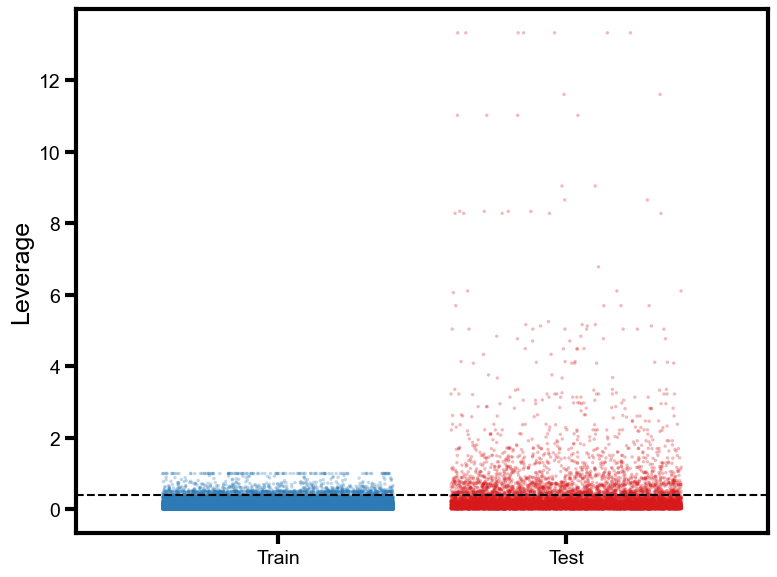

Warning threshold h* = 0.4107


In [17]:
rng = np.random.default_rng(26)
train_x = rng.uniform(-0.4, 0.4, size=len(train_leverage))
test_x = rng.uniform(0.6, 1.4, size=len(test_leverage))

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(train_x, train_leverage, s=6, alpha=0.3, color="#2c7bb6", edgecolors="none", label=f"Train (n={n})")
ax.scatter(test_x, test_leverage, s=6, alpha=0.3, color="#d7191c", edgecolors="none", label=f"Test (n={len(test_leverage)})")
ax.axhline(warning_leverage, color="black", linestyle="--", linewidth=1.5, label=f"Warning threshold h*={warning_leverage:.3f}")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Train", "Test"])
ax.set_xlim(-0.7, 1.7)
ax.set_ylabel("Leverage")

plt.tight_layout()
fig.savefig("applicability_domain_leverage.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Warning threshold h* = {warning_leverage:.4f}")

# Training and Test Set UMAP

In [20]:
from utils import (
    featurize_ccs_dataset,
    load_or_build_fingerprint_vocabulary,
    build_feature_matrix_sparse,
)

FP_VOCAB_FILE = "../../ccsbase2_fp_vocab.joblib"

# adducts with >= 50 occurrences across train + test -- matches the adduct
# vocabulary used when training the production XGBoostRegressor
combined_adduct_counts = pd.concat([train_df["adduct"], test_df["adduct"]]).value_counts()
adducts = sorted(combined_adduct_counts[combined_adduct_counts >= 50].index.tolist())

fp_vocab = load_or_build_fingerprint_vocabulary(DB_PATH, FP_VOCAB_FILE)
fp_index = build_fingerprint_index(fp_vocab)

# same base descriptors (molecular weight, adduct mass, adduct one-hot) + sparse
# Morgan fingerprint columns fed to the XGBoostRegressor -- this can take a
# few minutes since every molecule's fingerprint is recomputed with rdkit
base_features_train, fp_dicts_train, _, metadata_train = featurize_ccs_dataset(train_df, adducts)
base_features_test, fp_dicts_test, _, metadata_test = featurize_ccs_dataset(test_df, adducts)

# subclass per row, aligned to the feature matrices via the metadata returned
# by featurize_ccs_dataset (not train_df/test_df directly) -- reused below for
# coloring the PCA/UMAP plots
subclass_train = np.array([m[1] for m in metadata_train])
subclass_test = np.array([m[1] for m in metadata_test])

X_train_full = build_feature_matrix_sparse(base_features_train, fp_dicts_train, fp_index)
X_test_full = build_feature_matrix_sparse(base_features_test, fp_dicts_test, fp_index)

print(f"Full XGBoost feature set: {X_train_full.shape[1]} columns")
print(f"Train: {X_train_full.shape[0]} rows | Test: {X_test_full.shape[0]} rows")

# The production vocabulary (fp_vocab above) includes every fragment seen in as
# few as ONE molecule (min_molecule_count=1 when it was built). That's fine for
# XGBoost, which is scale-invariant, but it's poison for scaled PCA: a fragment
# seen in 1 of 53k molecules has a std of ~0.004, so standardizing divides that
# molecule's value by a near-zero number and blows it out to a huge outlier --
# which is exactly the "everything collapsed near 0 except a few points near
# 1000" pattern in the plots below. Prune to fragments seen in >= 40 training
# molecules (same threshold used in analysis/reviews/pca_umap_breakdown.ipynb)
# for the PCA/UMAP views only -- the XGBoostRegressor itself still trains on
# the full, unpruned vocabulary.
fp_vocab_pca = build_fingerprint_vocabulary(fp_dicts_train, min_molecule_count=40)
fp_index_pca = build_fingerprint_index(fp_vocab_pca)

X_train_pca = build_feature_matrix_sparse(base_features_train, fp_dicts_train, fp_index_pca)
X_test_pca = build_feature_matrix_sparse(base_features_test, fp_dicts_test, fp_index_pca)

print(f"PCA/UMAP feature set (fingerprints pruned to >= 40 train molecules): {X_train_pca.shape[1]} columns")


def plot_embedding(Z_train, Z_test, subclass_train, subclass_test, palette, xlabel, ylabel, file_prefix, point_size=12):
    """Scatter Z_train/Z_test (2D embeddings) colored by `palette` (subclass -> color),
    with any subclass not in the palette (incl. null) drawn in black behind it.
    No legend -- the palette mapping is printed separately. One shared, square
    axis range across both splits so train/test are directly comparable."""
    combined_min = min(Z_train.min(), Z_test.min())
    combined_max = max(Z_train.max(), Z_test.max())
    pad = 0.05 * (combined_max - combined_min)
    lo, hi = combined_min - pad, combined_max + pad

    for Z, subclasses, split_name in [(Z_train, subclass_train, "train"), (Z_test, subclass_test, "test")]:
        subclasses = np.asarray(subclasses)
        is_top10 = np.isin(subclasses, list(palette.keys()))

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(
            Z[~is_top10, 0], Z[~is_top10, 1],
            color="black", s=point_size, alpha=0.15, edgecolors="none", zorder=1,
        )
        ax.scatter(
            Z[is_top10, 0], Z[is_top10, 1],
            color=[palette[sc] for sc in subclasses[is_top10]], s=point_size, alpha=0.85, edgecolors="none", zorder=2,
        )
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")

        # force identical tick marks on both axes -- matplotlib's default locator
        # picks ticks per-axis based on rendered label space, so it can pick a
        # different count/spacing for x vs y even when xlim/ylim are numerically
        # identical. Pin both axes to the same tick array to guarantee they match.
        shared_ticks = ax.get_xticks()
        shared_ticks = shared_ticks[(shared_ticks >= lo) & (shared_ticks <= hi)]
        ax.set_xticks(shared_ticks)
        ax.set_yticks(shared_ticks)

        plt.tight_layout()
        fig.savefig(f"{file_prefix}_{split_name}.png", dpi=300, bbox_inches="tight")
        plt.show()

Full XGBoost feature set: 39294 columns
Train: 54382 rows | Test: 11771 rows
PCA/UMAP feature set (fingerprints pruned to >= 40 train molecules): 4752 columns


In [21]:
import matplotlib.colors as mcolors

top20_subclasses_combined = (
    pd.concat([train_df["subclass"], test_df["subclass"]])
    .dropna()
    .value_counts()
    .head(20)
    .index
    .tolist()
)

cmap = plt.cm.tab20
subclass_palette = {sc: mcolors.to_hex(cmap(i)) for i, sc in enumerate(top20_subclasses_combined)}

print("Subclass -> color (top 20 across train + test, null excluded; everything else is black):")
for subclass, color in subclass_palette.items():
    print(f"  {color}  {subclass}")

Subclass -> color (top 20 across train + test, null excluded; everything else is black):
  #1f77b4  Amino acids, peptides, and analogues
  #aec7e8  Benzoic acids and derivatives
  #ff7f0e  Anilides
  #ffbb78  Benzenesulfonamides
  #2ca02c  Biphenyls and derivatives
  #98df8a  Piperazines
  #d62728  Carbonyl compounds
  #ff9896  Triazoles
  #9467bd  Pyrazoles
  #c5b0d5  Benzodiazines
  #8c564b  Aryl thioethers
  #c49c94  Carbohydrates and carbohydrate conjugates
  #e377c2  Tetrazoles
  #f7b6d2  Triradylcglycerols
  #7f7f7f  Phenylpyrrolidines
  #c7c7c7  Glycerophosphocholines
  #bcbd22  Diphenylmethanes
  #dbdb8d  Glycerophosphoethanolamines
  #17becf  Purines and purine derivatives
  #9edae5  Benzo-1,4-dioxanes


/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: divide by zero encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: overflow encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: invalid value encountered in matmul
  matvec=lambda x: X @ x - offset @ x,


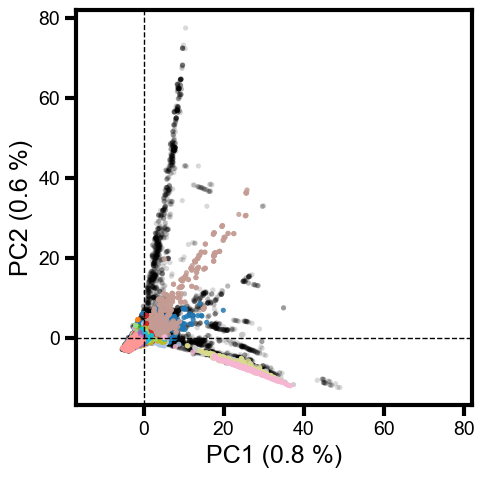

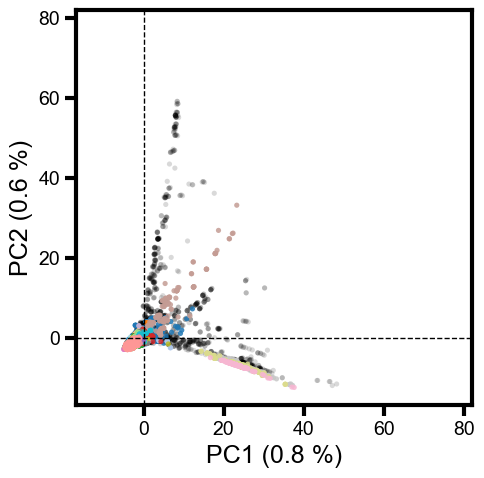

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_sparse = StandardScaler(with_mean=False).fit(X_train_pca)
X_train_sparse_scaled = scaler_sparse.transform(X_train_pca)
X_test_sparse_scaled = scaler_sparse.transform(X_test_pca)

pca_sparse = PCA(n_components=2, svd_solver="arpack", random_state=26).fit(X_train_sparse_scaled)
Z_train_sparse = pca_sparse.transform(X_train_sparse_scaled)
Z_test_sparse = pca_sparse.transform(X_test_sparse_scaled)

var1 = pca_sparse.explained_variance_ratio_[0] * 100
var2 = pca_sparse.explained_variance_ratio_[1] * 100

plot_embedding(
    Z_train_sparse, Z_test_sparse,
    subclass_train, subclass_test, subclass_palette,
    xlabel=f"PC1 ({var1:.1f} %)", ylabel=f"PC2 ({var2:.1f} %)",
    file_prefix="PCA_sparse_scaled", point_size=14,
)

/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP hybrid input: 4752 columns (Scaled Base + Unscaled Sparse FPs)


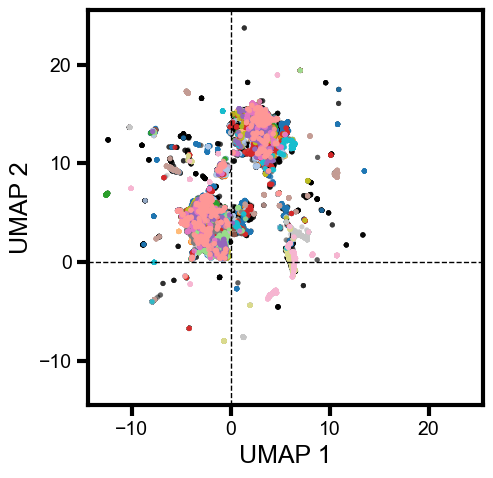

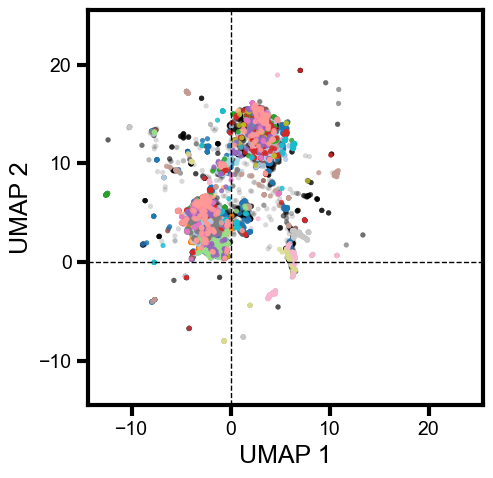

In [23]:
import umap
import scipy.sparse as sp
import numpy as np
from utils import vectorize_fingerprints_sparse
from sklearn.preprocessing import StandardScaler

# 1. Convert base features to dense numpy arrays
base_train_arr = np.array(base_features_train, dtype=np.float32)
base_test_arr = np.array(base_features_test, dtype=np.float32)

# 2. Scale ONLY the base features 
# This prevents molecular weight/mass from dominating the distance calculations
scaler = StandardScaler()
base_train_scaled = scaler.fit_transform(base_train_arr)
base_test_scaled = scaler.transform(base_test_arr)

# 3. Vectorize the sparse fingerprints directly (no scaling, no PCA)
fps_train_sparse = vectorize_fingerprints_sparse(fp_dicts_train, fp_index_pca)
fps_test_sparse = vectorize_fingerprints_sparse(fp_dicts_test, fp_index_pca)

# 4. Horizontally stack the scaled base features with the unscaled sparse fingerprints
X_train_hybrid = sp.hstack([base_train_scaled, fps_train_sparse], format="csr")
X_test_hybrid = sp.hstack([base_test_scaled, fps_test_sparse], format="csr")

print(f"UMAP hybrid input: {X_train_hybrid.shape[1]} columns (Scaled Base + Unscaled Sparse FPs)")

# 5. Run UMAP directly on the hybrid sparse matrix
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.0001,
    metric="cosine",  # Cosine handles the mix of scaled continuous and count data well
)

U_train = reducer.fit_transform(X_train_hybrid)
U_test = reducer.transform(X_test_hybrid)

# 6. Plot
plot_embedding(
    U_train, U_test,
    subclass_train, subclass_test, subclass_palette,
    xlabel="UMAP 1", ylabel="UMAP 2",
    file_prefix="UMAP_hybrid_cosine", point_size=14,
)

# Signed Adduct Mass as a Feature Significance

In [26]:
from scipy.stats import wilcoxon

WITH_ADDUCT_MASS_CSV = "../testset_predictions_ohe_adductmass.csv"
WITHOUT_ADDUCT_MASS_CSV = "../testset_predictions_ohe.csv"

with_df = pd.read_csv(WITH_ADDUCT_MASS_CSV)
without_df = pd.read_csv(WITHOUT_ADDUCT_MASS_CSV)


print(f"With adduct mass: {len(with_df)} rows | Without adduct mass: {len(without_df)} rows")

With adduct mass: 12802 rows | Without adduct mass: 12802 rows


In [27]:
merged = with_df.merge(
    without_df, on=["SMILES", "Adduct", "CCS_True"], suffixes=("_with", "_without"),
)

print(f"Matched rows: {len(merged)} / {len(with_df)} (with) / {len(without_df)} (without)")

ccs_true = merged["CCS_True"]
rel_err_with = (merged["CCS_Pred_with"] - ccs_true).abs() / ccs_true * 100
rel_err_without = (merged["CCS_Pred_without"] - ccs_true).abs() / ccs_true * 100

print(f"With adduct mass    | mean RE: {rel_err_with.mean():.4f}% | median RE: {rel_err_with.median():.4f}%")
print(f"Without adduct mass | mean RE: {rel_err_without.mean():.4f}% | median RE: {rel_err_without.median():.4f}%")

Matched rows: 12802 / 12802 (with) / 12802 (without)
With adduct mass    | mean RE: 1.7333% | median RE: 1.2308%
Without adduct mass | mean RE: 1.7508% | median RE: 1.2456%


In [28]:
statistic, p_value = wilcoxon(rel_err_with, rel_err_without)

print(f"Paired Wilcoxon signed-rank test | statistic={statistic:.2f} | p={p_value:.4e}")
print(
    "Significant at alpha=0.05" if p_value < 0.05 else "Not significant at alpha=0.05",
    "-- adduct mass", "reduces" if rel_err_with.median() < rel_err_without.median() else "increases",
    "median relative error",
)

Paired Wilcoxon signed-rank test | statistic=39748978.00 | p=3.3432e-03
Significant at alpha=0.05 -- adduct mass reduces median relative error


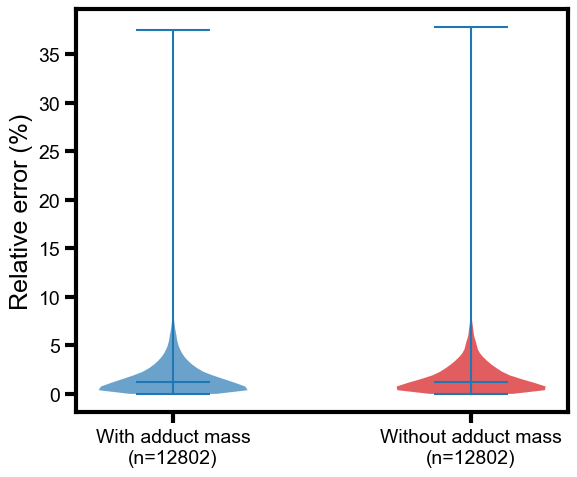

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))

parts = ax.violinplot([rel_err_with, rel_err_without], positions=[0, 1], showmedians=True)
for pc, color in zip(parts["bodies"], ["#2c7bb6", "#d7191c"]):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax.set_xticks([0, 1])
ax.set_xticklabels([f"With adduct mass\n(n={len(merged)})", f"Without adduct mass\n(n={len(merged)})"])
ax.set_ylabel("Relative error (%)")

plt.tight_layout()
plt.show()

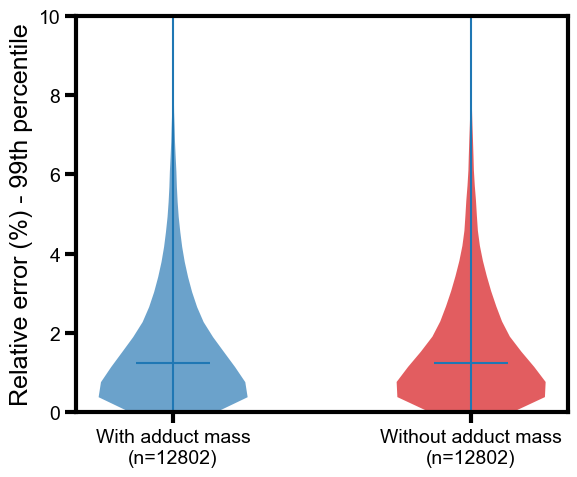

In [47]:
fig, ax = plt.subplots(figsize=(6, 5))

parts = ax.violinplot([rel_err_with, rel_err_without], positions=[0, 1], showmedians=True)
for pc, color in zip(parts["bodies"], ["#2c7bb6", "#d7191c"]):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax.set_xticks([0, 1])
ax.set_xticklabels([f"With adduct mass\n(n={len(merged)})", f"Without adduct mass\n(n={len(merged)})"])
ax.set_ylabel("Relative error (%) - 99th percentile")
ax.set_ylim(0, 10)  # zoomed to ~99th percentile -- a long tail (max ~38%) otherwise dwarfs the median difference

plt.tight_layout()
plt.show()

# Applicability Domain Analysis

In [37]:
import sys
import os

sys.path.append(os.path.abspath("../.."))

from utils import (
    train_test_split_custom,
    calculate_sparse_fingerprints,
    build_fingerprint_vocabulary,
    build_fingerprint_index
)
def vectorize_sparse_fp(fp_dict: dict, fp_index: dict) -> np.ndarray:
    vector = np.zeros(len(fp_index), dtype=np.float32)
    for env_id, count in fp_dict.items():
        column = fp_index.get(env_id)
        if column is not None:
            vector[column] = count
    return vector

DB_PATH = "../CCSMLDatabase.db"

def vectorize_fingerprints(fp_dicts, fp_index) -> np.ndarray:
    return np.array([vectorize_sparse_fp(fp, fp_index) for fp in fp_dicts])


# pure data split -- no model training -- matches train.py's own default args
train_test_split_custom(
    database_file=DB_PATH,
    test_size=0.2,
    random_state=26,
    use_metlin=True,
)

train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")


print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")

56429 rows split by subclass
5110 rows split by class
20 rows split by superclass
4594 rows with no superclass/class/subclass -- added to training only
53351 train rows
12802 test rows
Train: 53351 rows | Test: 12802 rows


In [38]:
fp_min_count = 40

train_fps = calculate_sparse_fingerprints(train_df["smi"])
fp_vocab = build_fingerprint_vocabulary(train_fps, fp_min_count)
fp_index = build_fingerprint_index(fp_vocab)

test_fps = calculate_sparse_fingerprints(test_df["smi"])

X_train = vectorize_fingerprints(train_fps, fp_index).astype(np.float64)
X_test = vectorize_fingerprints(test_fps, fp_index).astype(np.float64)

p = X_train.shape[1]
n = X_train.shape[0]
print(f"Fingerprint vocabulary: {p} substructures kept (min_count={fp_min_count})")
print(f"Train: {n} molecules | Test: {len(X_test)} molecules")

Fingerprint vocabulary: 4709 substructures kept (min_count=40)
Train: 53351 molecules | Test: 12802 molecules


In [39]:
# pseudo-inverse, not a plain inverse -- fingerprint columns are collinear/sparse
# enough that X_train^T X_train is often singular or near-singular
XtX_pinv = np.linalg.pinv(X_train.T @ X_train)


def compute_leverage(X, XtX_pinv):
    return np.sum((X @ XtX_pinv) * X, axis=1)


train_leverage = compute_leverage(X_train, XtX_pinv)
test_leverage = compute_leverage(X_test, XtX_pinv)

warning_leverage = 3 * p / n

print(f"Warning leverage threshold h* = 3p/n = {warning_leverage:.4f}")
print(f"Train molecules above threshold: {(train_leverage > warning_leverage).sum()} / {n} "
      f"({(train_leverage > warning_leverage).mean() * 100:.1f}%)")
print(f"Test molecules above threshold (outside applicability domain): "
      f"{(test_leverage > warning_leverage).sum()} / {len(test_leverage)} "
      f"({(test_leverage > warning_leverage).mean() * 100:.1f}%)")

/var/folders/rd/mnd__7n57pgf3m882g88r7pw0000gn/T/ipykernel_25665/4137010015.py:3: RuntimeWarning: divide by zero encountered in matmul
  XtX_pinv = np.linalg.pinv(X_train.T @ X_train)
/var/folders/rd/mnd__7n57pgf3m882g88r7pw0000gn/T/ipykernel_25665/4137010015.py:3: RuntimeWarning: overflow encountered in matmul
  XtX_pinv = np.linalg.pinv(X_train.T @ X_train)
/var/folders/rd/mnd__7n57pgf3m882g88r7pw0000gn/T/ipykernel_25665/4137010015.py:3: RuntimeWarning: invalid value encountered in matmul
  XtX_pinv = np.linalg.pinv(X_train.T @ X_train)
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value enco

Warning leverage threshold h* = 3p/n = 0.2648
Train molecules above threshold: 920 / 53351 (1.7%)
Test molecules above threshold (outside applicability domain): 964 / 12802 (7.5%)


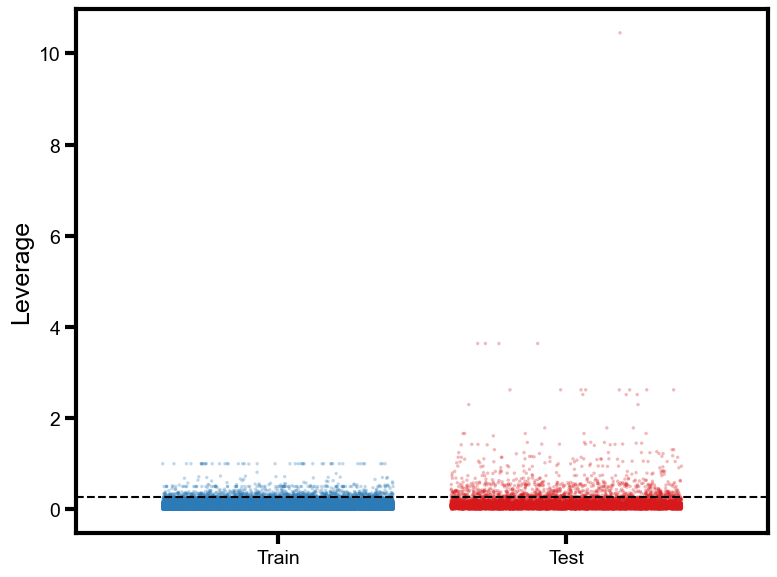

Warning threshold h* = 0.2648


In [40]:
rng = np.random.default_rng(26)
train_x = rng.uniform(-0.4, 0.4, size=len(train_leverage))
test_x = rng.uniform(0.6, 1.4, size=len(test_leverage))

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(train_x, train_leverage, s=6, alpha=0.3, color="#2c7bb6", edgecolors="none", label=f"Train (n={n})")
ax.scatter(test_x, test_leverage, s=6, alpha=0.3, color="#d7191c", edgecolors="none", label=f"Test (n={len(test_leverage)})")
ax.axhline(warning_leverage, color="black", linestyle="--", linewidth=1.5, label=f"Warning threshold h*={warning_leverage:.3f}")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Train", "Test"])
ax.set_xlim(-0.7, 1.7)
ax.set_ylabel("Leverage")

plt.tight_layout()
fig.savefig("applicability_domain_leverage.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Warning threshold h* = {warning_leverage:.4f}")

# Adduct Performance as a Function of Training Data

In [41]:
from scipy.stats import spearmanr


train_df = pd.read_csv("../train_data.csv")
preds_df = pd.read_csv("../testset_predictions_ohe_adductmass.csv")

train_counts = train_df["adduct"].value_counts().rename("N_train")

In [ ]:
def compute_adduct_metrics(df):
    rows = []
    for adduct, group in df.groupby("Adduct"):
        y_true = group["CCS_True"].to_numpy(dtype=float)
        y_pred = group["CCS_Pred"].to_numpy(dtype=float)
        abs_error = np.abs(y_true - y_pred)
        rel_error = abs_error / y_true * 100
        rows.append({
            "Adduct": adduct,
            "N_test": len(group),
            "MAE": abs_error.mean(),
            "MDAE": np.median(abs_error),
            "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
            "MRE_%": rel_error.mean(),
            "MDRE_%": np.median(rel_error),
        })
    return pd.DataFrame(rows)


table = compute_adduct_metrics(preds_df).merge(train_counts, left_on="Adduct", right_index=True, how="left")
table["N_train"] = table["N_train"].fillna(0).astype(int)
table = table.sort_values("N_train", ascending=False).reset_index(drop=True)

Spearman correlation (log10 N_train vs. MDRE%), n=36 adducts: rho=-0.3082, p=0.0674


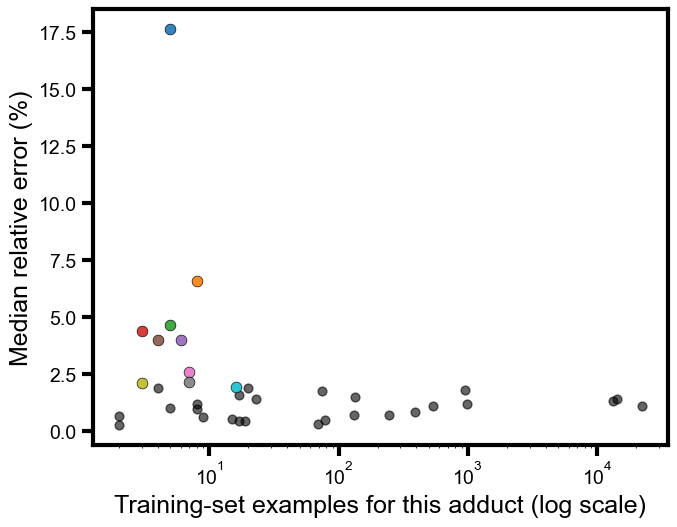

In [46]:
corr_subset = table[table["N_train"] > 0]
rho, p = spearmanr(np.log10(corr_subset["N_train"]), corr_subset["MDRE_%"])
print(f"Spearman correlation (log10 N_train vs. MDRE%), n={len(corr_subset)} adducts: rho={rho:.4f}, p={p:.4f}")

top10 = corr_subset.nlargest(10, "MDRE_%")
top10_adducts = top10["Adduct"].tolist()
is_top10 = corr_subset["Adduct"].isin(top10_adducts)

cmap = plt.get_cmap("tab10")
adduct_colors = {adduct: cmap(i) for i, adduct in enumerate(top10_adducts)}

fig, ax = plt.subplots(figsize=(7, 5.5))

for _, row in top10.iterrows():
    ax.scatter(row["N_train"], row["MDRE_%"], s=60, alpha=0.9,
               color=adduct_colors[row["Adduct"]], edgecolors="black", linewidth=0.5,
               zorder=3, label=row["Adduct"])

other = corr_subset[~is_top10]
ax.scatter(other["N_train"], other["MDRE_%"], s=40, alpha=0.6, color="black", zorder=2, label="Other")

ax.set_xscale("log")
ax.set_xlabel("Training-set examples for this adduct (log scale)")
ax.set_ylabel("Median relative error (%)")

plt.tight_layout()
plt.show()

# Verify OOD is truly distributionally different from CCSBase2 train set

In [48]:
import sqlite3

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

OOD_CSV = "../datasets/ood_datasets/ood_testset.csv"

conn = sqlite3.connect(DB_PATH)
db_df = pd.read_sql_query("SELECT smi FROM master_clean WHERE smi IS NOT NULL", conn)
conn.close()

ood_df = pd.read_csv(OOD_CSV)
ood_df = ood_df[ood_df["smi"].notna() & (ood_df["smi"].str.len() > 0)]


print(f"CCSMLDatabase (master_clean): {len(db_df)} rows | OOD set (deduped): {len(ood_df)} rows")

CCSMLDatabase (master_clean): 66153 rows | OOD set (deduped): 5827 rows


In [49]:
db_smi = db_df["smi"].drop_duplicates().reset_index(drop=True)
ood_smi = ood_df["smi"].drop_duplicates().reset_index(drop=True)

print(f"Unique CCSMLDatabase molecules: {len(db_smi)}")
print(f"Unique OOD molecules: {len(ood_smi)}")
print(f"Exact smi overlap: {len(set(db_smi) & set(ood_smi))}")

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, includeChirality=True)


def compute_fingerprints(smiles_series):
    fps = []
    for smi in smiles_series:
        mol = Chem.MolFromSmiles(smi)
        mol = Chem.AddHs(mol)
        fps.append(morgan_generator.GetSparseCountFingerprint(mol))
    return fps


db_fps = compute_fingerprints(db_smi)
ood_fps = compute_fingerprints(ood_smi)

Unique CCSMLDatabase molecules: 31286
Unique OOD molecules: 3154
Exact smi overlap: 0


In [51]:
NEAR_DUPLICATE_THRESHOLD = 0.70

nn_similarity = np.array([
    max(DataStructs.BulkTanimotoSimilarity(ood_fp, db_fps)) for ood_fp in ood_fps
])

print(f"Nearest-neighbor Tanimoto similarity to CCSMLDatabase | mean: {nn_similarity.mean():.4f} | median: {np.median(nn_similarity):.4f}")
print(
    f"OOD molecules with a near-duplicate in CCSMLDatabase (similarity > {NEAR_DUPLICATE_THRESHOLD}): "
    f"{(nn_similarity > NEAR_DUPLICATE_THRESHOLD).sum()} / {len(nn_similarity)} "
    f"({(nn_similarity > NEAR_DUPLICATE_THRESHOLD).mean() * 100:.1f}%)"
)

Nearest-neighbor Tanimoto similarity to CCSMLDatabase | mean: 0.6081 | median: 0.6226
OOD molecules with a near-duplicate in CCSMLDatabase (similarity > 0.7): 0 / 3154 (0.0%)


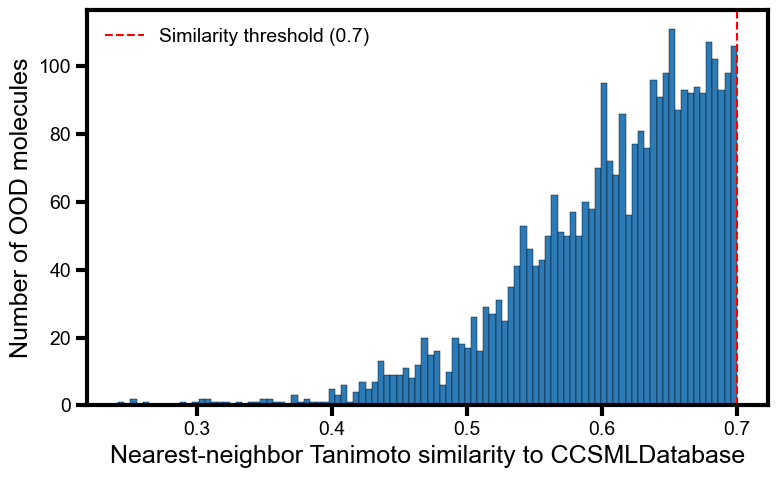

In [54]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(nn_similarity, bins=100, color="#2c7bb6", edgecolor="black", linewidth=0.3)
ax.axvline(
    NEAR_DUPLICATE_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
    label=f"Similarity threshold ({NEAR_DUPLICATE_THRESHOLD})",
)
ax.legend(frameon=False)

ax.set_xlabel("Nearest-neighbor Tanimoto similarity to CCSMLDatabase")
ax.set_ylabel("Number of OOD molecules")

plt.tight_layout()
plt.show()

# Histogram of CCS Replicate Values within 1% SMILES-Group Median Threshold

In [2]:
import sqlite3

TABLE = "master_nodimer"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query(
    f"SELECT smi, adduct, ccs, superclass, class, subclass FROM master_nodimer WHERE smi IS NOT NULL",
    conn,
)
conn.close()

n = df.shape[0]
df.columns

Index(['smi', 'adduct', 'ccs', 'superclass', 'class', 'subclass'], dtype='object')

In [3]:
CCS_OUTLIER_THRESHOLD_PCT = 1.0  # must match data.py's clean()

grouped_ccs = df.groupby(["smi", "adduct"])["ccs"]
group_size = grouped_ccs.transform("size")
group_median_ccs = grouped_ccs.transform("median")

df["deviation_pct"] = (df["ccs"] - group_median_ccs).abs() / group_median_ccs * 100

replicate_df = df[group_size >= 2]
n_measurements = len(replicate_df)
n_groups = replicate_df.groupby(["smi", "adduct"]).ngroups

print(f"Replicate measurements: {n_measurements} across {n_groups} (smi, adduct) groups")
print(f"Median deviation: {replicate_df['deviation_pct'].median():.3f}%")
print(f"Mean deviation: {replicate_df['deviation_pct'].mean():.3f}%")
print(
    f"Measurements beyond the {CCS_OUTLIER_THRESHOLD_PCT}% threshold: "
    f"{(replicate_df['deviation_pct'] > CCS_OUTLIER_THRESHOLD_PCT).mean() * 100:.1f}%"
)

Replicate measurements: 9294 across 3614 (smi, adduct) groups
Median deviation: 0.340%
Mean deviation: 0.842%
Measurements beyond the 1.0% threshold: 23.9%


Replicate measurements n=9294 across 3614 groups
99th percentile: 6.66


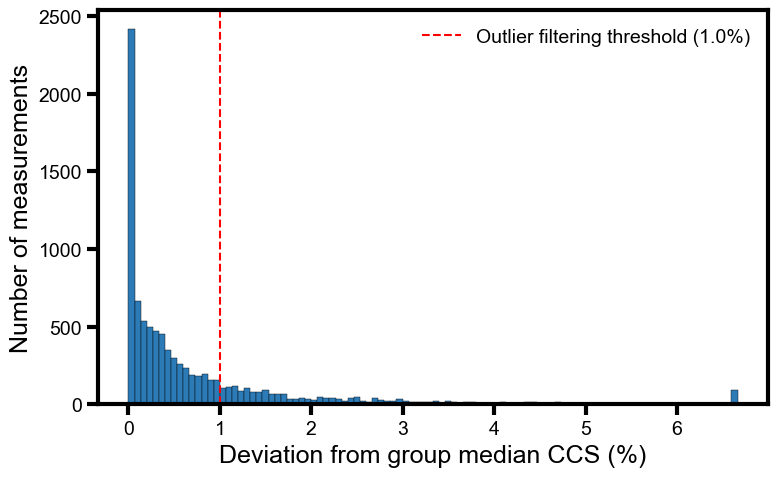

In [9]:
# same distribution, x-axis clipped to the 99th percentile -- the raw histogram above
# is typically dominated by a long tail from a small number of highly discordant groups
clip = replicate_df["deviation_pct"].quantile(0.99)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(replicate_df["deviation_pct"].clip(upper=clip), bins=100, color="#2c7bb6", edgecolor="black", linewidth=0.3)
ax.axvline(
    CCS_OUTLIER_THRESHOLD_PCT, color="red", linestyle="--", linewidth=1.5,
    label=f"Outlier filtering threshold ({CCS_OUTLIER_THRESHOLD_PCT}%)",
)
ax.legend(frameon=False)

ax.set_xlabel(f"Deviation from group median CCS (%)")
ax.set_ylabel("Number of measurements")
print(f"Replicate measurements n={n_measurements} across {n_groups} groups")
print(f"99th percentile: {clip:.2f}")
plt.tight_layout()
plt.show()

# Bootstrap test for model significance

In [4]:
MODEL_FILES = {
    "CCSBase2": {
        "test": "../testset_predictions_ohe_adductmass.csv",
        "ood": "../ood_testset_predictions.csv",
    },
    "CCSBase": {
        "test": "../../c3sdb/c3sdb_preds.csv",
        "ood": "../../c3sdb/ood_testset_preds.csv",
    },
    "DeepCCS": {
        "test": "../../DeepCCS/test_data_preds.csv",
        "ood": "../../DeepCCS/ood_testset_preds.csv",
    },
    "GraphCCS": {
        "test": "../../GraphCCS/test_data_predictions.csv",
        "ood": "../../GraphCCS/ood_testset_preds.csv",
    },
    "SigmaCCS2": {
        "test": "../../SigmaCCS2/test_data_predictions.csv",
        "ood": "../../SigmaCCS2/ood_testset_predictions.csv",
    },
    "Linear Regression": {
        "test": "../../naive_models/linear_regression_testset_predictions.csv",
        "ood": "../../naive_models/linear_regression_ood_predictions.csv",
    },
    "SVR": {
        "test": "../../naive_models/svr_mqn_testset_predictions.csv",
        "ood": "../../naive_models/svr_mqn_ood_predictions.csv",
    },
    "MLP": {
        "test": "../../naive_models/mlp_mqn_testset_predictions.csv",
        "ood": "../../naive_models/mlp_mqn_ood_predictions.csv",
    },
}


SEED = 26
N_BOOT = 1000
def normalize_predictions(path):
    df = pd.read_csv(path)
    colmap = {c.lower(): c for c in df.columns}

    def pick(*names):
        for n in names:
            if n.lower() in colmap:
                return colmap[n.lower()]
        raise KeyError(f"None of {names} found in {path}: {list(df.columns)}")

    out = pd.DataFrame({
        "SMILES": df[pick("SMILES", "smi")],
        "Adduct": df[pick("Adduct", "adduct")],
        "CCS_True": df[pick("CCS_True", "ccs")].astype(float),
        "CCS_Pred": df[pick("CCS_Pred", "ccs_pred")].astype(float),
    })
    return out.dropna(subset=["CCS_Pred"])


test_preds = {name: normalize_predictions(paths["test"]) for name, paths in MODEL_FILES.items()}
ood_preds = {name: normalize_predictions(paths["ood"]) for name, paths in MODEL_FILES.items()}

for name in MODEL_FILES:
    print(f"{name:20s} test n={len(test_preds[name]):6d} | ood n={len(ood_preds[name]):6d}")

CCSBase2             test n= 12802 | ood n=  5827
CCSBase              test n= 12802 | ood n=  5827
DeepCCS              test n= 12802 | ood n=  5789
GraphCCS             test n= 12787 | ood n=  5825
SigmaCCS2            test n= 12791 | ood n=  5827
Linear Regression    test n= 12802 | ood n=  5827
SVR                  test n= 12802 | ood n=  5827
MLP                  test n= 12802 | ood n=  5827


In [8]:
def mae_fn(y_true, y_pred):
    return np.mean(np.abs(y_pred - y_true))


def bootstrap_metric(df, metric_fn, n_boot=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    y_true = df["CCS_True"].to_numpy(dtype=float)
    y_pred = df["CCS_Pred"].to_numpy(dtype=float)
    n = len(df)
    stats = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        stats[i] = metric_fn(y_true[idx], y_pred[idx])
    return stats


boot_test = {name: bootstrap_metric(df, mae_fn) for name, df in test_preds.items()}
boot_ood = {name: bootstrap_metric(df, mae_fn) for name, df in ood_preds.items()}

ci_rows = []
for split_name, boot in (("test", boot_test), ("ood", boot_ood)):
    for name, dist in boot.items():
        lo, hi = np.percentile(dist, [2.5, 97.5])
        ci_rows.append({"split": split_name, "model": name, "MAE_mean": dist.mean(),
                        "CI_2.5%": lo, "CI_97.5%": hi})

ci_table = pd.DataFrame(ci_rows).round(3)
display(ci_table)

,split,model,MAE_mean,CI_2.5%,CI_97.5%
0,test,CCSBase2,3.332,3.270,3.393
1,test,CCSBase,4.653,4.544,4.771
2,test,DeepCCS,4.169,4.100,4.232
3,test,GraphCCS,3.411,3.350,3.476
4,test,SigmaCCS2,3.865,3.801,3.927
5,test,Linear Regression,5.535,5.455,5.620
6,test,SVR,4.481,4.402,4.556
7,test,MLP,4.711,4.638,4.783
8,ood,CCSBase2,5.071,4.761,5.467
9,ood,CCSBase,5.457,5.109,5.899


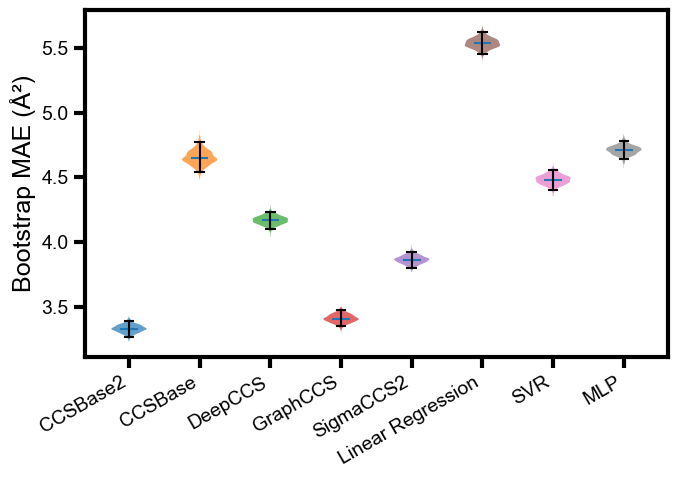

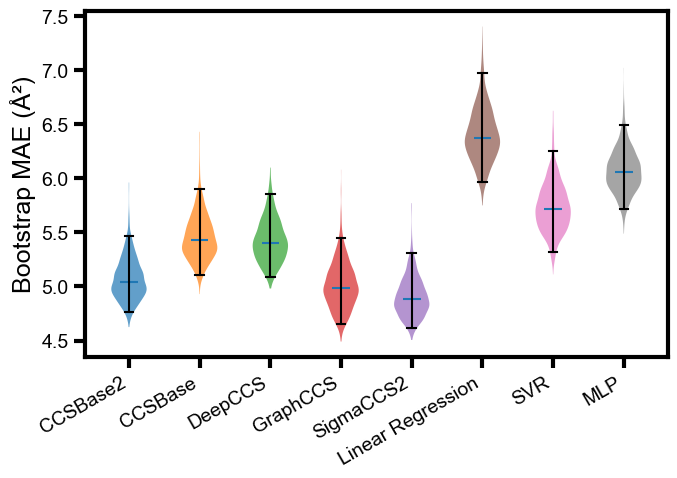

In [9]:
model_order = list(MODEL_FILES.keys())
colors = plt.cm.tab10.colors

for boot, title in ((boot_test, "In-distribution test set"), (boot_ood, "OOD test set")):
    fig, ax = plt.subplots(figsize=(7, 5))
    data = [boot[name] for name in model_order]
    parts = ax.violinplot(data, positions=range(len(model_order)), showmedians=True, showextrema=False)
    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

    # overlay the actual 95% CI (2.5th/97.5th percentile of the bootstrap distribution)
    # in place of violinplot's default min/max whiskers
    for i, name in enumerate(model_order):
        lo, hi = np.percentile(boot[name], [2.5, 97.5])
        ax.plot([i, i], [lo, hi], color="black", linewidth=1.5, zorder=3)
        ax.plot([i - 0.06, i + 0.06], [lo, lo], color="black", linewidth=1.5, zorder=3)
        ax.plot([i - 0.06, i + 0.06], [hi, hi], color="black", linewidth=1.5, zorder=3)

    ax.set_xticks(range(len(model_order)))
    ax.set_xticklabels(model_order, rotation=30, ha="right")
    ax.set_ylabel("Bootstrap MAE (Å²)")
    plt.tight_layout()
    plt.show()